##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [2]:
!pip install keras-cv tensorflow matplotlib pillow numpy

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 2.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 4.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 6.2 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 9.2 MB/s  0:00:03 eta 0:00:01
  Created wheel for promise: filename=promise-2.3-py3-none-any.whl size=21582 sha256=9bcda25a35c8a1e41e71173b2a160a8868103950950e41678961c03e84fe053a
  Stored in directory: /Users/jayanalarifi/Library/Caches/pip/wheels/54/4e/28/3ed0e1c8a752867445bab994d2340724928aa3ab059c57c8db
Successfully built promise
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [keras-cv]/17 [keras-cv]w-datasets]


In [7]:
!pip uninstall -y opencv-python
!pip install numpy==1.26.4
!pip install opencv-python==4.9.0.80

Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.7/55.7 MB 4.1 MB/s  0:00:13m0:00:0100:01


In [9]:
!pip install opencv-python==4.9.0.80


Image: boat.jpeg
boat: 0.994

Image: bottle.jpeg
bottle: 0.957

Image: motorbike.jpeg
bicycle: 0.696

Image: sheep.jpeg
sheep: 0.997
sheep: 0.224

Image: train.jpeg
train: 0.922
train: 0.383


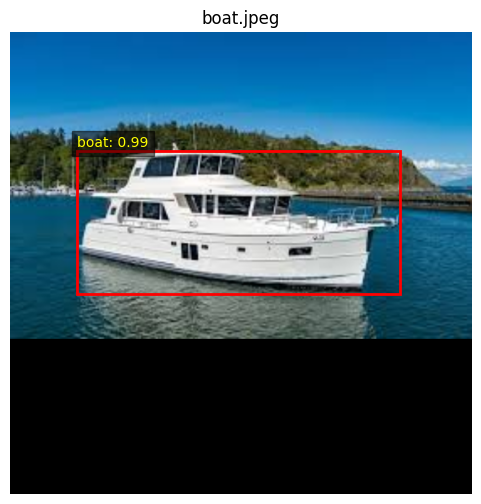

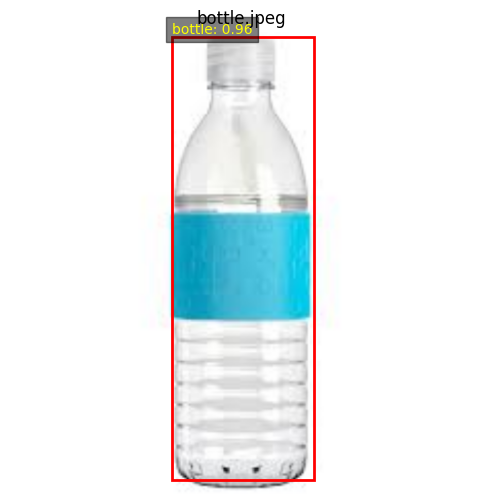

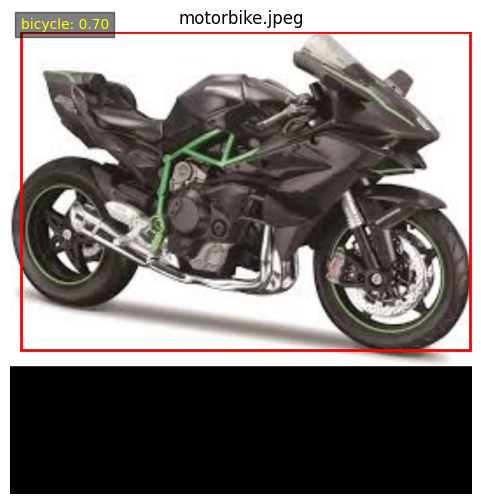

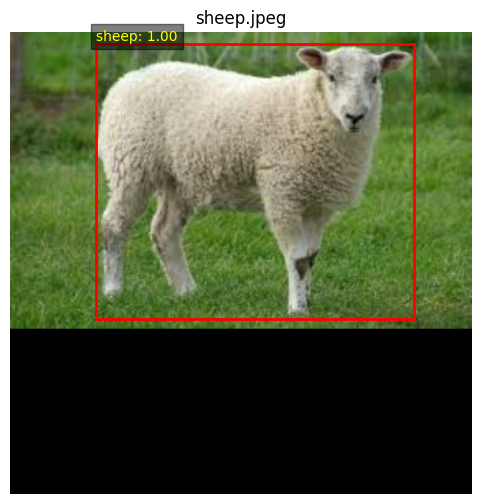

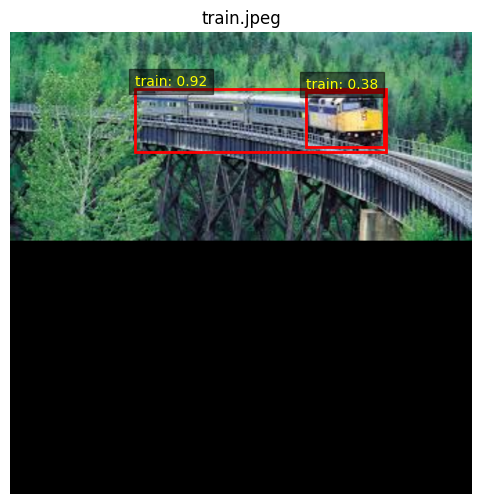

In [12]:
import os
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import keras_cv
from keras_cv import visualization

# Load pre-trained YOLOv8 model
yolo = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

# Image paths
image_paths = [
    "/Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab04-object-detection/images/boat.jpeg",
    "/Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab04-object-detection/images/bottle.jpeg",
    "/Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab04-object-detection/images/motorbike.jpeg",
    "/Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab04-object-detection/images/sheep.jpeg",
    "/Users/jayanalarifi/Desktop/comvisionlabs/arti560-computer-vision-labs/lab04-object-detection/images/train.jpeg"
]

# Load images
images = [np.array(Image.open(path).convert("RGB")) for path in image_paths]

# Resize images for inference
inference_resizing = keras_cv.layers.Resizing(
    640, 640,
    pad_to_aspect_ratio=True,
    bounding_box_format="xywh"
)

images_resized = np.array([inference_resizing(img) for img in images])

# Run predictions
predictions = yolo.predict(images_resized, verbose=0)

# Pascal VOC class mapping
voc_classes = {
    0: "aeroplane", 1: "bicycle", 2: "bird", 3: "boat", 4: "bottle",
    5: "bus", 6: "car", 7: "cat", 8: "chair", 9: "cow",
    10: "diningtable", 11: "dog", 12: "horse", 13: "motorbike", 14: "person",
    15: "pottedplant", 16: "sheep", 17: "sofa", 18: "train", 19: "tvmonitor"
}

# Print detected classes and confidence scores
for i in range(len(predictions["confidence"])):
    print(f"\nImage: {os.path.basename(image_paths[i])}")
    valid = predictions["confidence"][i] >= 0

    confs = predictions["confidence"][i][valid]
    clss = predictions["classes"][i][valid].astype(int)

    for c, k in zip(confs, clss):
        print(f"{voc_classes[k]}: {float(c):.3f}")

# Visualize predictions without OpenCV
import matplotlib.patches as patches

for i in range(len(images_resized)):
    fig, ax = plt.subplots(1, figsize=(6,6))
    ax.imshow(images_resized[i].astype("uint8"))

    boxes = predictions["boxes"][i]
    classes = predictions["classes"][i]
    confs = predictions["confidence"][i]

    for box, cls, conf in zip(boxes, classes, confs):
        if conf < 0.3:
            continue

        x, y, w, h = box

        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        label = f"{voc_classes[int(cls)]}: {conf:.2f}"
        ax.text(
            x,
            y - 5,
            label,
            color="yellow",
            fontsize=10,
            bbox=dict(facecolor="black", alpha=0.5)
        )

    ax.set_title(os.path.basename(image_paths[i]))
    ax.axis("off")
    plt.show()


### Detection Results

| Image File | Objects Detected Correctly | Confidence Scores | Missed / Incorrectly Labeled Objects |
|------------|-----------------------------|------------------|--------------------------------------|
| boat.jpeg | boat | boat: 0.994 | none |
| bottle.jpeg | bottle | bottle: 0.957 | none |
| motorbike.jpeg | none | bicycle: 0.696 | motorbike incorrectly labeled as bicycle |
| sheep.jpeg | sheep | sheep: 0.997, sheep: 0.224 | none |
| train.jpeg | train | train: 0.922, train: 0.383 | none |